In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

In [3]:
datafile = r'Dataset/portland_housing.xlsx'
dataframe = pd.read_excel(datafile)

df = dataframe[['livingArea', 'bathrooms', 'bedrooms', 'lotSize', 'address/zipcode', 'price']]
df.info()
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25731 entries, 0 to 25730
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   livingArea       25266 non-null  float64
 1   bathrooms        25247 non-null  float64
 2   bedrooms         24961 non-null  float64
 3   lotSize          22841 non-null  float64
 4   address/zipcode  25731 non-null  int64  
 5   price            25731 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 1.2 MB
<class 'pandas.DataFrame'>
Index: 22239 entries, 0 to 25730
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   livingArea       22239 non-null  float64
 1   bathrooms        22239 non-null  float64
 2   bedrooms         22239 non-null  float64
 3   lotSize          22239 non-null  float64
 4   address/zipcode  22239 non-null  int64  
 5   price            22239 non-null  int64  
dtypes: float64(4), int64

In [5]:
X = df[['livingArea', 'bathrooms', 'bedrooms', 'lotSize']].values#.to_numpy()#, 'address/zipcode']]
Y = df['price'].values#.to_numpy()

print(f"Shape of training X {X.shape}")
print(f"Shape of training Y {Y.shape}")

from random import randint
seed = randint(1, 100)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=seed)

print(f"Shape of training X living area {X_train[:10, 0]/1000}")
print(f"Shape of training X bathrooms {X_train[:10, 1]}")
print(f"Shape of training X bedrooms {X_train[:10, 2]}")
print(f"Shape of training X lot size {X_train[:10, 3]/1000}")

X_train[:, 0] = X_train[:, 0]/1000
X_train[:, 3] = X_train[:, 3]/1000

Shape of training X (22239, 4)
Shape of training Y (22239,)
Shape of training X living area [ 1.981  2.58   2.315  1.5    3.199  1.314  1.814 10.071  2.889  1.567]
Shape of training X bathrooms [3. 2. 3. 2. 3. 3. 2. 6. 3. 3.]
Shape of training X bedrooms [3. 4. 4. 3. 4. 3. 3. 6. 3. 4.]
Shape of training X lot size [ 3.049  8.276 10.454  9.583 10.454 12.632  2.613 43.56  10.018  0.871]


C:\Users\rperdomo\AppData\Local\Temp\ipykernel_12780\954698084.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\rperdomo\AppData\Local\Temp\ipykernel_12780\954698084.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\rperdomo\AppData\Local\Temp\ipykernel_12780\954698084.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\rperdomo\AppData\Local\Temp\ipykernel_12780\954698084.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument

Text(0.5, 1.0, 'Land Lot Size vs House Price')

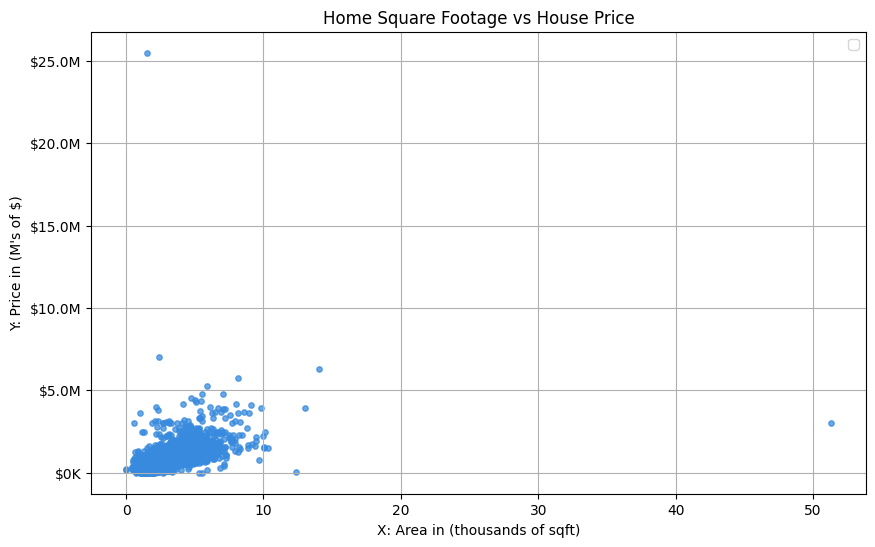

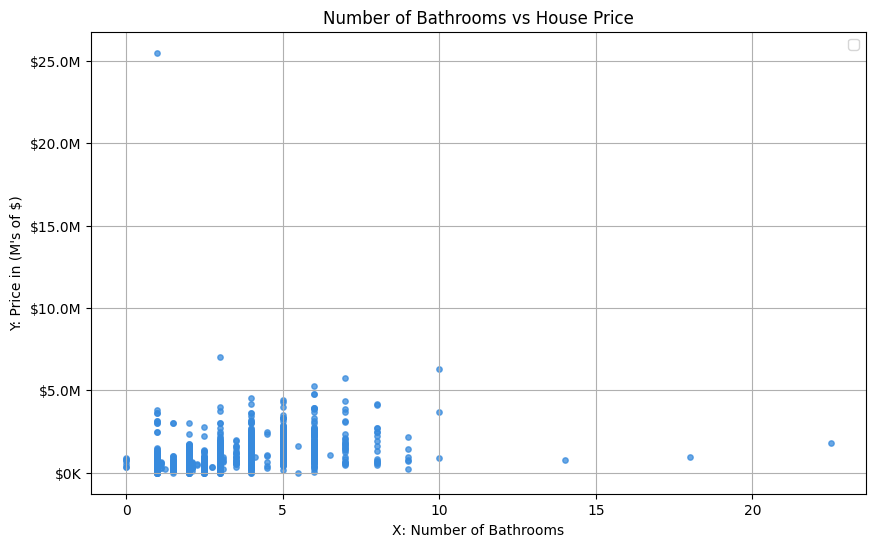

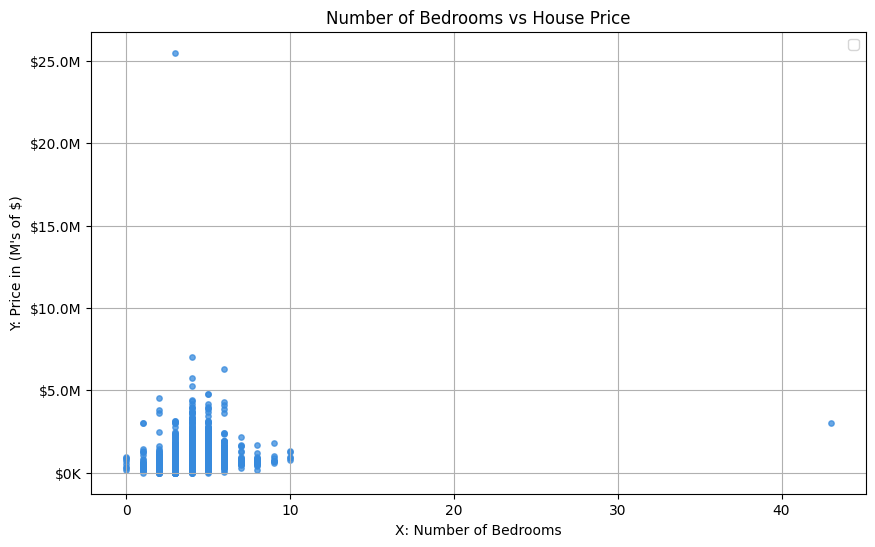

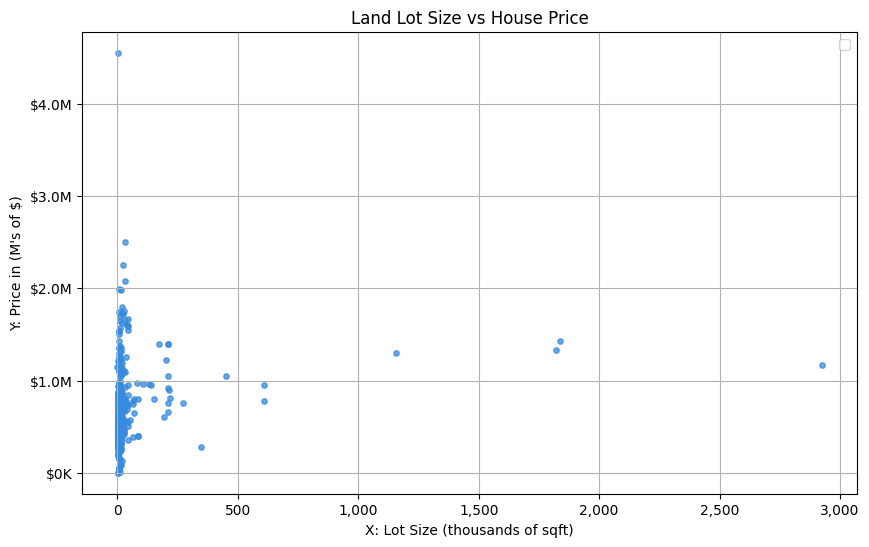

In [7]:
########## printing graphs step ###########
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[:, 0], Y_train,s=15,alpha=0.75,color='#378ADD')
ax.set_xlabel("X: Area in (thousands of sqft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Home Square Footage vs House Price")

########## printing graphs step ##########
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[:, 1], Y_train,s=15,alpha=0.75,color='#378ADD')
ax.set_xlabel("X: Number of Bathrooms")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Number of Bathrooms vs House Price")

########## printing graphs step ##########
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[:, 2], Y_train,s=15,alpha=0.75,color='#378ADD')
ax.set_xlabel("X: Number of Bedrooms")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Number of Bedrooms vs House Price")

########## printing graphs step ##########
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[:1000, 3], Y_train[:1000],s=15,alpha=0.75,color='#378ADD')
ax.set_xlabel("X: Lot Size (thousands of sqft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Land Lot Size vs House Price")

Ordinary Least Squares Linear Model

In [8]:
LR = LinearRegression()
scale = StandardScaler()

X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

LR.fit(X_train_scaled, Y_train)

print(f"Slope: {LR.coef_}, Bias: {LR.intercept_}.")

OLS_Test_Pred = LR.predict(X_test_scaled)

Slope: [215638.85969903  43219.97483168 -15752.46254348   1586.39424367], Bias: 602990.7212073521.


Text(0.5, 1.0, 'Home Square Footage vs House Price')

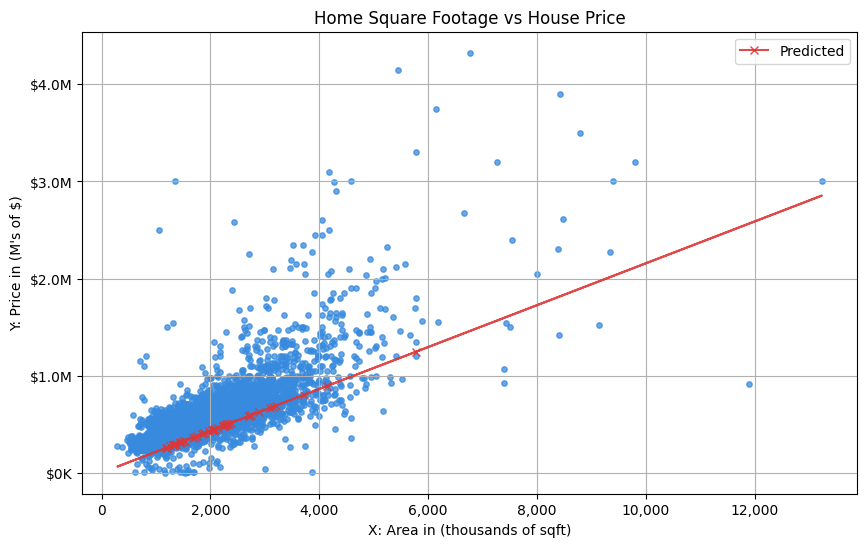

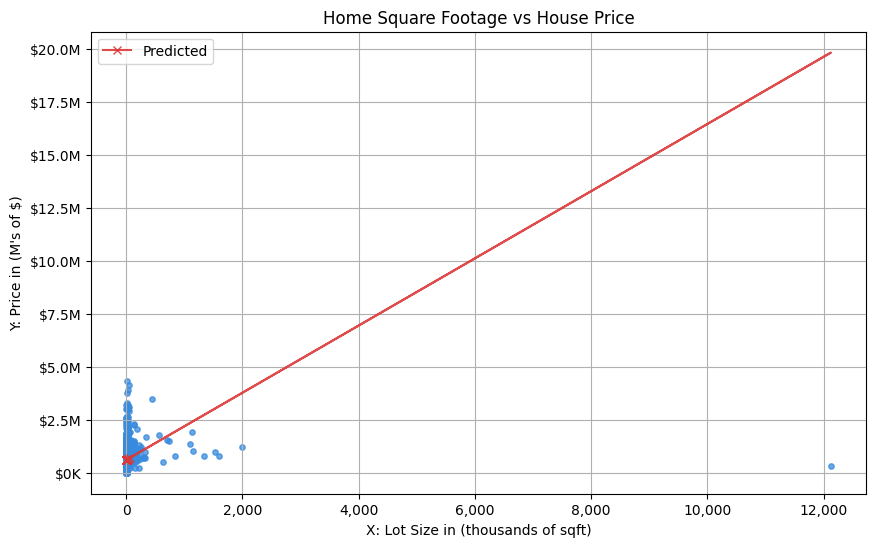

In [19]:
########## Price due to home size ###########
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_test_scaled[:, 0], Y_test,s=15,alpha=0.75,color='#378ADD')
ax.plot(X_test_scaled[:, 0], (X_test_scaled[:, 0]*LR.coef_[0] + LR.intercept_)/1000,alpha=0.9,color="#DD3737",marker='x', markevery=100,label='Predicted')
ax.set_xlabel("X: Area in (thousands of sqft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Home Square Footage vs House Price")

########## Price due to lot size ###########
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_test_scaled[:, 3], Y_test,s=15,alpha=0.75,color='#378ADD')
ax.plot(X_test_scaled[:, 3], (X_test_scaled[:, 3]*LR.coef_[3] + LR.intercept_),alpha=0.9,color="#DD3737",marker='x', markevery=100,label='Predicted')
ax.set_xlabel("X: Lot Size in (thousands of sqft)")
ax.set_ylabel("Y: Price in (M's of $)", rotation=90)
ax.grid()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K' if x < 1e6 else f'${x/1e6:.1f}M'))

ax.legend()
ax.set_title("Home Square Footage vs House Price")

In [9]:
MSE_loss = mean_squared_error(y_true=Y_test, y_pred=OLS_Test_Pred)
MAE_loss = mean_absolute_error(y_true=Y_test, y_pred=OLS_Test_Pred)

print(f"Mean Square Loss {MSE_loss}, The Mean Absolute Loss {MAE_loss}")


Mean Square Loss 2.3738733606255485e+17, The Mean Absolute Loss 439277313.80524176


In [10]:
X2 = df[['livingArea', 'lotSize']].values#.to_numpy()#, 'address/zipcode']]

X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    X2, Y, test_size=0.8, random_state=seed)

LR2 = LinearRegression()
scale2 = StandardScaler()

X_train_scaled2 = scale.fit_transform(X_train2)
X_test_scaled2 = scale.transform(X_test2)

LR2.fit(X_train_scaled2, Y_train2)

print(f"Slope: {LR2.coef_}, Bias: {LR2.intercept_}.")

OLS_Test_Pred2 = LR2.predict(X_test_scaled2)

MSE_loss2 = mean_squared_error(y_true=Y_test2, y_pred=OLS_Test_Pred2)
MAE_loss2 = mean_absolute_error(y_true=Y_test2, y_pred=OLS_Test_Pred2)

print(f"Mean Square Loss {MSE_loss2}, The Mean Absolute Loss {MAE_loss2}")


Slope: [222543.57992463  42175.95564633], Bias: 604961.9736901282.
Mean Square Loss 581098488924.267, The Mean Absolute Loss 134163.13083478966
